In [ ]:
# %%
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import kagglehub
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn import metrics

In [2]:
# %%
path = kagglehub.dataset_download("sheemazain/house-price-predication")

files = os.listdir(path)
file_path = os.path.join(path, files[0])

df = pd.read_csv(file_path)

print(df.head())
print(df.info())

                  date      price  bedrooms  bathrooms  sqft_living  sqft_lot  \
0  2014-05-02 00:00:00   313000.0       3.0       1.50         1340      7912   
1  2014-05-02 00:00:00  2384000.0       5.0       2.50         3650      9050   
2  2014-05-02 00:00:00   342000.0       3.0       2.00         1930     11947   
3  2014-05-02 00:00:00   420000.0       3.0       2.25         2000      8030   
4  2014-05-02 00:00:00   550000.0       4.0       2.50         1940     10500   

   floors  waterfront  view  condition  sqft_above  sqft_basement  yr_built  \
0     1.5           0     0          3        1340              0      1955   
1     2.0           0     4          5        3370            280      1921   
2     1.0           0     0          4        1930              0      1966   
3     1.0           0     0          4        1000           1000      1963   
4     1.0           0     0          4        1140            800      1976   

   yr_renovated                    str

In [3]:
# %%
if "date" in df.columns:
    df["date"] = pd.to_datetime(df["date"])
    df["year"] = df["date"].dt.year
    df.drop("date", axis=1, inplace=True)

if "street" in df.columns:
    df.drop("street", axis=1, inplace=True)

# Remove invalid values
df = df[df["price"] > 0]

# Remove outliers
df = df[df["price"] < df["price"].quantile(0.97)]

# Drop missing
df = df.dropna()

In [4]:
# %%
if "yr_renovated" in df.columns:
    df["renovated"] = (df["yr_renovated"] > 0).astype(int)

df["total_sqft"] = df["sqft_living"] + df["sqft_basement"]
df["bed_bath_ratio"] = df["bedrooms"] / (df["bathrooms"] + 1)

In [5]:
# %%
if "city" in df.columns:
    top_cities = df["city"].value_counts().nlargest(10).index
    df["city"] = df["city"].apply(lambda x: x if x in top_cities else "other")

df = pd.get_dummies(df, drop_first=True)

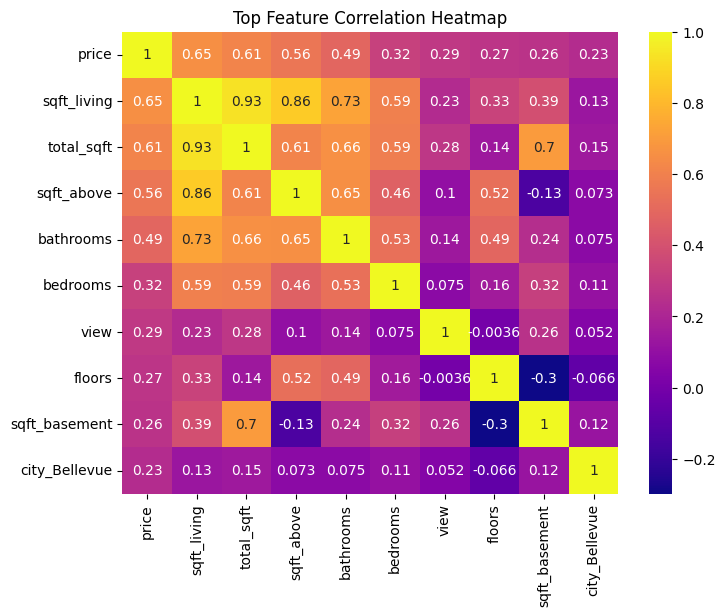

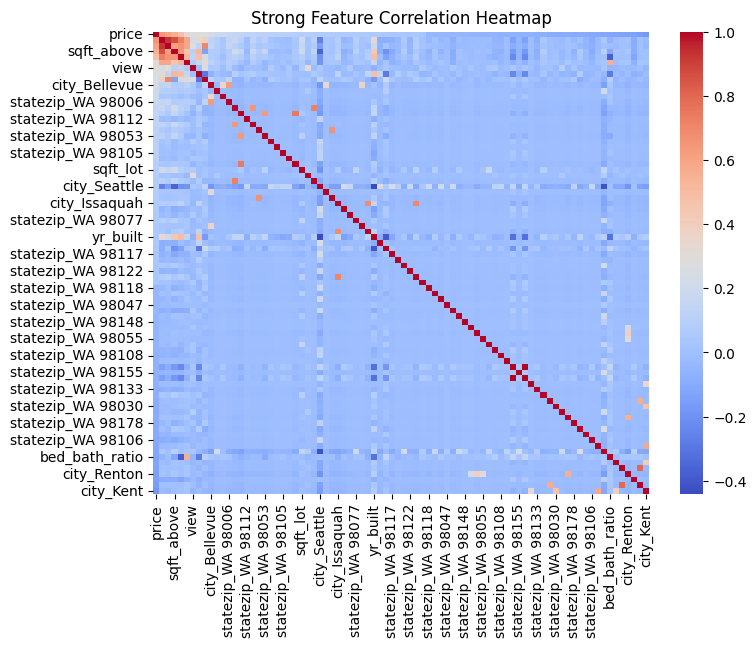

In [6]:
# %%
corr_matrix = df.corr()
price_corr = corr_matrix["price"].sort_values(ascending=False)

top_features = price_corr.index[:10]

plt.figure(figsize=(8,6))
sns.heatmap(df[top_features].corr(), annot=True, cmap="plasma")
plt.title("Top Feature Correlation Heatmap")
plt.show()

important_features = price_corr[abs(price_corr) > 0.03].index

plt.figure(figsize=(8,6))
sns.heatmap(df[important_features].corr(), cmap="coolwarm")
plt.title("Strong Feature Correlation Heatmap")
plt.show()

In [7]:
# %%
X = df.drop("price", axis=1)
X = X[important_features.drop("price")]

y_log = np.log(df["price"])
y = df["price"]

In [8]:
corr_matrix = df.corr()
price_corr = corr_matrix["price"].sort_values(ascending=False)

print("\nCorrelation with Price:\n", price_corr)

important_features = price_corr[abs(price_corr) > 0.03].index


Correlation with Price:
 price                1.000000
sqft_living          0.653260
total_sqft           0.611032
sqft_above           0.557628
bathrooms            0.491662
                       ...   
city_Renton         -0.137435
statezip_WA 98168   -0.139763
city_Federal Way    -0.158721
city_Kent           -0.176453
year                      NaN
Name: price, Length: 103, dtype: float64


In [9]:
# %%
X_train, X_test, y_train_log, y_test_log, y_train, y_test = train_test_split(
    X, y_log, y, test_size=0.2, random_state=42
)

# Align columns
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (3531, 81)
Test shape: (883, 81)


In [10]:
# %%
feature_names = X_train.columns

In [11]:
# %%
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [12]:
# %%
model = LinearRegression()
model.fit(X_train, y_train_log)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [13]:
test_data_prediction = model.predict(X_test)
print(test_data_prediction)

[13.12833364 13.23862834 13.00220075 13.26101832 13.04945222 12.92929003
 12.82089298 13.1841282  13.1619645  12.8026232  13.6343311  13.8117659
 12.34789651 13.65422779 12.66447529 13.09539187 12.68268427 12.82605736
 13.46312575 13.39371806 12.93863607 13.35870275 12.46968888 12.15147774
 12.78131041 13.40614863 13.36942233 12.5604773  12.81977858 13.39950749
 13.04673527 12.33554541 12.87072373 13.01572283 13.22393732 13.58182824
 13.23878701 14.45855564 12.8743043  12.6167428  13.53283042 13.0841793
 13.80688178 13.27879349 13.42747327 13.47246439 13.60067302 11.8434239
 13.48981765 13.75480996 13.49880285 13.22276105 12.45779589 13.18646573
 13.36409026 13.10504816 14.35178623 13.21512982 13.02468528 13.57527858
 13.42766335 12.88447418 12.57168045 12.32145108 13.50416741 13.5959169
 12.47288963 13.21421312 13.55085623 12.68873592 13.28850035 12.57200869
 12.75295969 13.32434262 13.9914603  12.71450799 13.16020357 13.3105476
 13.08399574 12.72401351 13.12296486 12.84845384 12.6072

In [14]:
# %%
coeff_df = pd.DataFrame(model.coef_, feature_names, columns=["Coefficient"])
coeff_df = coeff_df.sort_values(by="Coefficient", ascending=False)

print("\nFeature Coefficients:\n")
print(coeff_df.head(10))


Feature Coefficients:

               Coefficient
city_Seattle      0.329299
city_other        0.192468
renovated         0.150368
city_Bellevue     0.139016
city_Kent         0.120876
sqft_above        0.110550
city_Kirkland     0.108069
sqft_living       0.093852
city_Redmond      0.077435
city_Renton       0.074328


In [15]:
# %%
y_pred_log = model.predict(X_test)

# Prevent overflow
y_pred_log = np.clip(y_pred_log, -10, 20)

y_pred = np.exp(y_pred_log)

In [16]:
# %%
rmse = np.sqrt(metrics.mean_squared_error(y_test, y_pred))
r2 = metrics.r2_score(y_test, y_pred)

print("\nModel Performance:")
print("Train R2 (log):", model.score(X_train, y_train_log))
print("Test R2:", r2)
print("RMSE:", rmse)


Model Performance:
Train R2 (log): 0.8036425705467466
Test R2: 0.7213410919960989
RMSE: 120951.23509171398


In [17]:
# %%
sample = X_test[0:1]
pred = np.exp(model.predict(sample))

print("Predicted Price:", pred[0])
print("Actual Price:", y_test.iloc[0])

Predicted Price: 502994.0580479035
Actual Price: 499500.0


In [18]:
# %%
joblib.dump(model, "house_price_model.pkl")
print("Model saved successfully!")

Model saved successfully!


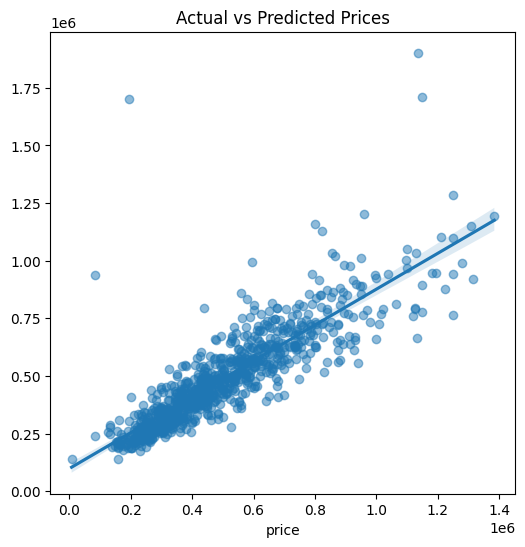

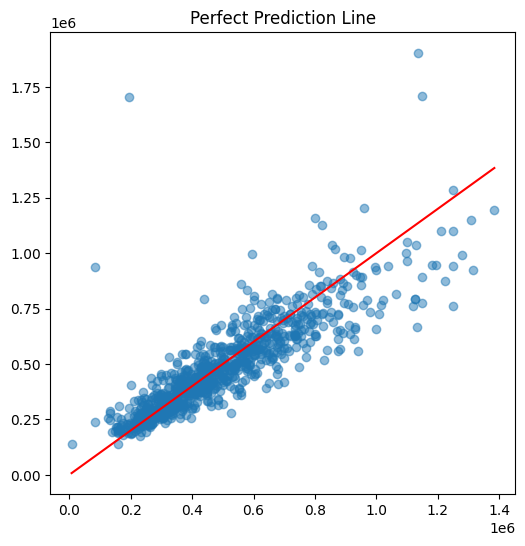

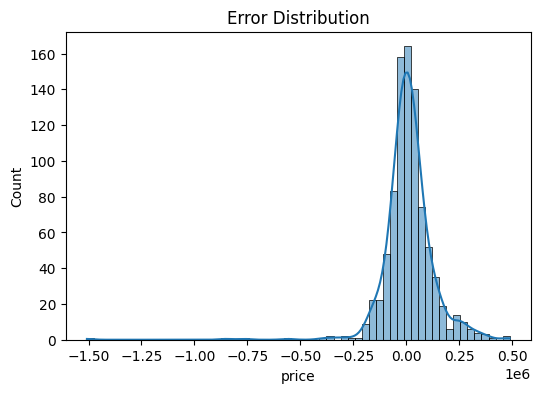

In [19]:
# %%
plt.figure(figsize=(6,6))
sns.regplot(x=y_test, y=y_pred, scatter_kws={"alpha":0.5})
plt.title("Actual vs Predicted Prices")
plt.show()

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')
plt.title("Perfect Prediction Line")
plt.show()

errors = y_test - y_pred

plt.figure(figsize=(6,4))
sns.histplot(errors, kde=True)
plt.title("Error Distribution")
plt.show()